En este programa vamos a estimar el valor de $\pi$ usando métodos MonteCarlo. Ver https://en.wikipedia.org/wiki/Monte_Carlo_method.

La idea es sencilla. Si tenemos un cuadrado de tamaño $1 \times 1$ en $x \in [0,1]$ y en $y \in [0,1]$, y un cuarto de círculo inscrito dentro de él (1 cuadrante de radio $r=1$), entonces sabemos que $A_{T} = 1$ y que $A_{circ/4} = \pi/4$. Entonces $A_{circ/4}/A_{T} = \pi/4$. 

Si ahora generamos $N$ puntos dentro del cuadrado de $1x1$ y llamamos red ($R$) a todos aquellos que caen dentro del círculo y blue ($B$) a todos aquellos que están fuera, entonces sabemos que $R + B = N$ y que $1 = A_{T} = (R+B)/N = A_{circ/4} + A_{resto}$, y por lo tanto $\rightarrow$

$\pi = \frac{4R}{N}$. 

In [1]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

In [2]:
def rand(a,b,N):
    # [a,b] = rango de generacion
    # N = numero de puntos a generar

    x_rand = np.random.uniform(a,b,N) # Vector de puntos generados

    return x_rand

In [3]:
def circ(x,y):

    radio_2 = x**2 + y**2 # r^2 = x^2 + y^2

    return radio_2

In [4]:
def Pi_MC(a,b,N):
    # [a,b] = rango de generacion
    # N = numero de puntos a generar

    x_rand = rand(a,b,N)
    y_rand = rand(a,b,N)

    Red = 0
    Blue = 0

    radio_2 = a**2 + b**2 # radio al cuadrado

    for k in range (0,N,1):
        if circ(x_rand[k],y_rand[k]) <= radio_2: 
            Red = Red + 1
        else:
            Blue = Blue + 1

    p_i = float(4*Red / N)

    return Red,p_i,x_rand,y_rand

VALOR DE PI ESTIMADO:

In [5]:
a=0.0
b=1.0
N=2500

R,p_i,x_rand,y_rand = Pi_MC(a,b,N)

print('El valor de pi estimado es de ',p_i,'.')
print('El numero de puntos que hay dentro de la circunferencia son',R,'de',N,'.')

El valor de pi estimado es de  3.0896 .
El numero de puntos que hay dentro de la circunferencia son 1931 de 2500 .


Ahora podemos probar a hacer un gráfico similar a la que hay en https://en.wikipedia.org/wiki/Monte_Carlo_method.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


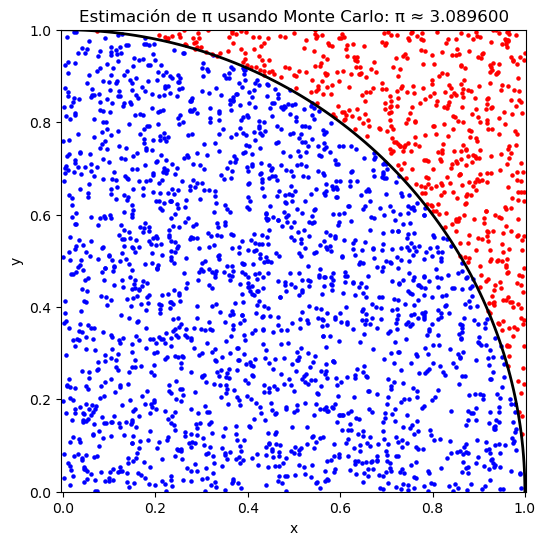

In [6]:
inside = x_rand**2 + y_rand**2 <= 1.0 

# Crear la figura
plt.figure(figsize=(6,6))
plt.scatter(x_rand[inside], y_rand[inside], color='blue', s=5, label='Dentro del círculo')
plt.scatter(x_rand[~inside], y_rand[~inside], color='red', s=5, label='Fuera del círculo')

# Dibujar la circunferencia (cuarto de círculo)
theta = np.linspace(0, np.pi/2, 100)
plt.plot(np.cos(theta), np.sin(theta), color='black', lw=2)

plt.title(f'Estimación de π usando Monte Carlo: π ≈ {p_i:.6f}')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()